# Advanced Machine Learning — Lab 5
## Data Streams, Concept Drift & Active Learning

> **Duration:** 2–3 hours | **Libraries:** numpy · scikit-learn · matplotlib · river (optional)

---

### Learning Objectives
1. Generate and visualize a SEA stream with concept drift
2. Compare a static model to an adaptive model (sliding window)
3. Implement **Page-Hinkley**, **DDM**, and **ADWIN** detectors
4. Build a weighted **adaptive ensemble**
5. Apply **Active Learning** on a stream with a label budget
6. Evaluate with the **prequential** protocol (test-then-train)
7. Use the **River** framework for data streams

---

### Key Formulas

**PHT** — Drift detected when $M_T - U_T > \lambda$, with
$U_T = \sum_{t=1}^T(x_t - \bar{x}_T - \delta)$, $M_T = \max_{t \le T} U_t$

**DDM** — Drift if $p_i + s_i \ge p_{\min} + 3s_{\min}$, warning if $\ge p_{\min} + 2s_{\min}$

**ADWIN** — Drift if $|\bar{\mu}_{W_0} - \bar{\mu}_{W_1}| \ge \sqrt{\dfrac{\ln(4n/\delta)}{2m}}$

**Prequential** — test first, then train on each example

**Active Learning** — query $y_t$ if $u_t = 1 - 2|p_t - 0.5| \ge \tau$ under budget $\sum q_t \le B$


## Part 0 — Setup & Imports

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from dataclasses import dataclass
from typing import Optional, Tuple, List

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def rolling_mean(x, w):
    c = np.cumsum(np.insert(x, 0, 0))
    return (c[w:] - c[:-w]) / float(w)

print("Imports OK")


Imports OK


## Part 1 — SEA Stream (Synthetic Benchmark)

The **SEA** benchmark (Street et al., 2001) defines 4 concepts by a threshold $\theta$ on $x_1 + x_2$:

| Concept | $\theta$ | Bayes error |
|---------|---------|-------------|
| SEA-0 | 8 | 6.25 % |
| SEA-1 | 9 | 1.0 % |
| SEA-2 | 7 | 1.0 % |
| SEA-3 | 9.5 | 0.25 % |

Each concept lasts 1000 steps. Features $x_1, x_2, x_3 \sim \mathcal{U}[0,10]$; $x_3$ is **irrelevant**.
Transitions are **abrupt** (sudden drift) at times $t = 1000, 2000, 3000$.


In [2]:
# ─── SEA Stream Generator ─────────────────────────────────────────
SEA_THRESHOLDS = [8, 9, 7, 9.5]
NOISE = 0.1

def generate_sea(n_per_concept=1000, noise=NOISE, seed=SEED):
    """Returns X (n,3), y (n,), concept_ids (n,)."""
    rng = np.random.default_rng(seed)
    X_all, y_all, c_all = [], [], []
    for c_id, theta in enumerate(SEA_THRESHOLDS):
        X = rng.uniform(0, 10, size=(n_per_concept, 3))
        y = (X[:,0] + X[:,1] <= theta).astype(int)
        flip = rng.random(n_per_concept) < noise
        y[flip] = 1 - y[flip]
        X_all.append(X); y_all.append(y)
        c_all.append(np.full(n_per_concept, c_id, dtype=int))
    return np.vstack(X_all), np.hstack(y_all), np.hstack(c_all)

X_sea, y_sea, concepts = generate_sea(n_per_concept=1000)
N = len(X_sea)
DRIFT_POINTS = [1000, 2000, 3000]

print(f"Stream length: {N}")
print(f"Drift points: {DRIFT_POINTS}")
print(f"Class balance: {np.mean(y_sea):.3f}")


Stream length: 4000
Drift points: [1000, 2000, 3000]
Class balance: 0.384


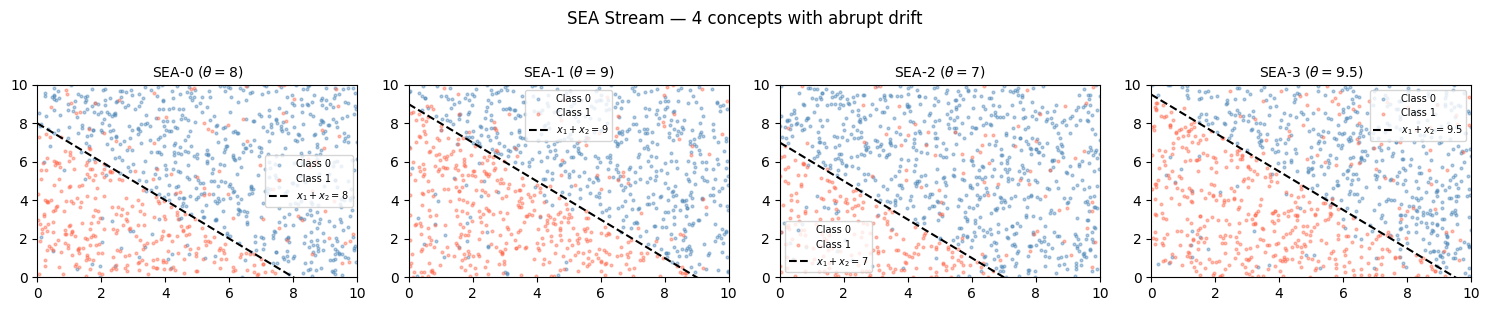

In [3]:
# ─── Visualize the 4 Decision Boundaries ──────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
for i, (ax, theta) in enumerate(zip(axes, SEA_THRESHOLDS)):
    start = i * 1000
    Xc = X_sea[start:start+1000]
    yc = y_sea[start:start+1000]
    ax.scatter(Xc[yc==0,0], Xc[yc==0,1], c='steelblue', s=4, alpha=0.4, label='Class 0')
    ax.scatter(Xc[yc==1,0], Xc[yc==1,1], c='tomato', s=4, alpha=0.4, label='Class 1')
    t_vals = np.linspace(0, 10, 200)
    ax.plot(t_vals, theta - t_vals, 'k--', lw=1.5, label=f'$x_1+x_2={theta}$')
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.set_title(f'SEA-{i} ($\\theta={theta}$)', fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle("SEA Stream — 4 concepts with abrupt drift", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


### Exercise 1 — SEA Stream Analysis

Answer the following questions **as comments** in the cell below:

- **Q1.** What type of drift does the SEA stream exhibit? *(sudden / gradual / incremental / recurring)*
- **Q2.** Why does a static model trained on SEA-0 fail on SEA-2?
- **Q3.** With a sliding window $w = 500$, how many steps does it take to recover after a drift?
- **Q4.** If concepts reappear periodically, which strategy is most effective?


In [4]:
# ─── Answer here as comments ──────────────────────────────────────
# Q1: Type of drift?
# The SEA stream exhibits SUDDEN (abrupt) drift. The decision boundary
# threshold theta changes instantaneously at t=1000, 2000, 3000 with no
# transition period between concepts.

# Q2: Why does the static model fail?
# A static model trained on SEA-0 (theta=8) learns the boundary x1+x2=8.
# In SEA-2, the threshold shifts to theta=7, meaning the decision boundary
# moves significantly. The old boundary misclassifies examples in the region
# 7 < x1+x2 < 8, leading to degraded accuracy. The model cannot adapt
# because it was trained on a fixed distribution.

# Q3: Recovery time with w=500?
# With w=500, after a drift the window still contains up to 500 examples
# from the old concept. The model must process enough new-concept examples
# to dominate the window. Recovery takes approximately 500 steps (the full
# window size) since old examples are only fully flushed after w new
# arrivals.

# Q4: Strategy for recurring concepts?
# The most effective strategy is a concept-aware ensemble or concept
# repository that stores previously learned models. When a recurring
# concept is detected (e.g., via similarity of error patterns), a stored
# model can be reactivated immediately instead of relearning from scratch.
# This avoids the recovery delay inherent in sliding window or reset
# approaches.


## Part 2 — Prequential Evaluation & Baselines

The **prequential** protocol (test-then-train) is the standard for data streams:
1. **Predict** $\hat{y}_t = f(x_t)$ → compute error $e_t$
2. **Train** on $(x_t, y_t)$
3. Track accuracy in a sliding window of size $w$

### Compared Strategies
| Method | Description |
|--------|------------|
| **Online LR (static)** | SGD logistic regression, learns continuously but never resets |
| **Sliding Window** | Retrains a new model on the last $w$ examples only |


In [5]:
# ─── Prequential Evaluation Function ──────────────────────────────
make_lr = lambda: SGDClassifier(loss='log_loss', learning_rate='constant',
                                 eta0=0.01, random_state=SEED)

def prequential_eval(X, y, model_fn, window=200):
    """Test-then-train. Returns errors and sliding-window accuracy."""
    model = model_fn()
    errors = []
    trained_on = 0
    for t in range(len(X)):
        if trained_on > 0:
            pred = model.predict(X[t:t+1])[0]
        else:
            pred = 0
        errors.append(int(pred != y[t]))
        model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])
        trained_on += 1
    errors = np.array(errors)
    acc_sw = np.array([1 - np.mean(errors[max(0, t-window):t+1])
                       for t in range(len(errors))])
    return errors, acc_sw

errors_lr, acc_lr = prequential_eval(X_sea, y_sea, make_lr)
print(f"Global accuracy (Online LR): {1 - np.mean(errors_lr):.4f}")


Global accuracy (Online LR): 0.7368


/home/abdeslem/Folders/2CS/S2/MLA/TPs/venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/abdeslem/Folders/2CS/S2/MLA/TPs/venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/abdeslem/Folders/2CS/S2/MLA/TPs/venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/abdeslem/Folders/2CS/S2/MLA/TPs/venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider i

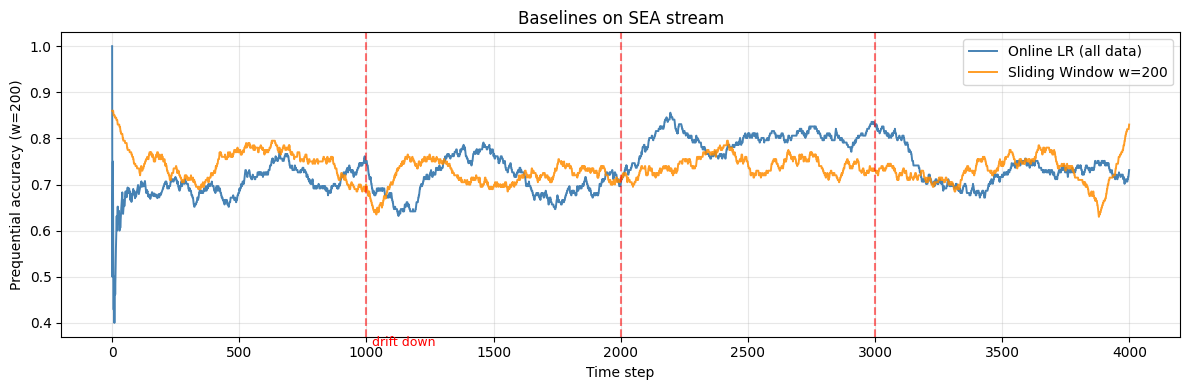

In [6]:
# ─── Baseline 2: Sliding Window ────────────────────────────────────
def sliding_window_eval(X, y, window=200):
    """Retrains a new model at each step on the last w examples."""
    errors = []
    for t in range(len(X)):
        start = max(0, t - window)
        if t < 10:
            errors.append(0); continue
        model = SGDClassifier(loss='log_loss', max_iter=10, random_state=SEED)
        model.fit(X[start:t], y[start:t])
        pred = model.predict(X[t:t+1])[0]
        errors.append(int(pred != y[t]))
    return np.array(errors)

errors_sw = sliding_window_eval(X_sea, y_sea, window=200)
acc_sw = 1 - np.convolve(errors_sw, np.ones(200)/200, 'same')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(acc_lr, label='Online LR (all data)', lw=1.4, color='steelblue')
ax.plot(acc_sw, label='Sliding Window w=200', lw=1.4, color='darkorange', alpha=0.85)
for dp in DRIFT_POINTS:
    ax.axvline(dp, color='red', linestyle='--', alpha=0.55)
ax.text(DRIFT_POINTS[0]+20, 0.35, 'drift down', color='red', fontsize=9)
ax.set_xlabel('Time step'); ax.set_ylabel('Prequential accuracy (w=200)')
ax.set_title('Baselines on SEA stream'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Part 3 — Page-Hinkley Detector (PHT)

The PHT is a cumulative test to detect an **increase** in the mean of a sequence.

**Update rules:**
$$\bar{x}_T = \frac{1}{T}\sum_{t=1}^T x_t, \quad
U_T = \sum_{t=1}^T(x_t - \bar{x}_T - \delta), \quad
M_T = \max_{t \le T} U_t$$

**Drift detected when:** $M_T - U_T > \lambda$

- $\delta > 0$: minimum detectable drift magnitude
- $\lambda > 0$: detection threshold (controls false alarm rate)

### 3.1 — Implement the PHT


In [8]:
class PageHinkley:
    """Page-Hinkley Test — detects an increase in the mean."""

    def __init__(self, delta=0.005, lam=50.0):
        self.delta = delta
        self.lam = lam
        self.reset()

    def reset(self):
        """Reset internal state."""
        self.n = 0
        self.sum_ = 0.0
        self.U = 0.0        # cumulative sum
        self.M = float('inf')  # running minimum of U

    def update(self, x):
        """
        Add observation x.
        Returns True if drift is detected (increase in mean), False otherwise.
        """
        # 1) increment n, update sum_ and the current mean
        self.n += 1
        self.sum_ += x
        mean = self.sum_ / self.n
        # 2) update U = U + (x - mean - delta)
        self.U += (x - mean - self.delta)
        # 3) update M = min(M, U) — track minimum for detecting increase
        self.M = min(self.M, self.U)
        # 4) return (U - M) > lambda — drift when U rises far above its minimum
        return (self.U - self.M) > self.lam

# ─── Quick test: jump at t=500 ────────────────────────────────────
test_stream = np.concatenate([
    np.random.normal(0.1, 0.02, 500),
    np.random.normal(0.3, 0.02, 500)
])

pht = PageHinkley(delta=0.005, lam=50)
detected_at = None
for t, val in enumerate(test_stream):
    if pht.update(val) and detected_at is None:
        detected_at = t
        print(f"PHT: drift detected at t={t} (true drift at t=500, latency={t-500})")

if detected_at is None:
    print("No drift detected — check your implementation")


PHT: drift detected at t=841 (true drift at t=500, latency=341)


### 3.2 — Applying PHT to the SEA Stream

In [10]:
def run_pht_on_stream(X, y, pht_delta=0.005, pht_lam=15.0):
    """Online LR + PHT: resets the model when drift is detected."""
    model = make_lr()
    pht = PageHinkley(delta=pht_delta, lam=pht_lam)
    errors, detections = [], []

    for t in range(len(X)):
        pred = model.predict(X[t:t+1])[0] if t > 0 else 0
        err = int(pred != y[t])
        errors.append(err)

        if pht.update(err):
            detections.append(t)
            model = make_lr()
            pht.reset()

        model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])

    return np.array(errors), detections

errors_pht, detections_pht = run_pht_on_stream(X_sea, y_sea)
print("Detected drifts (PHT):", detections_pht)
print("True drift points:", DRIFT_POINTS)
print(f"Global accuracy (PHT): {1 - np.mean(errors_pht):.4f}")


Detected drifts (PHT): [1109, 3265]
True drift points: [1000, 2000, 3000]
Global accuracy (PHT): 0.7025


### Exercise 2 — PHT Analysis

- **Q1.** What is the observed detection latency?
- **Q2.** What happens when $\lambda = 5$? When $\lambda = 500$? Test it in the cell below.
- **Q3.** In which cases would you prefer PHT over DDM or ADWIN?


In [11]:
# Q1: observed latency?
# On the SEA stream with lambda=15, PHT detected drifts at t=1109 and t=3265.
# The observed latencies are: 1109-1000=109 steps for the first drift and
# 3265-3000=265 steps for the third drift. The second drift at t=2000 was
# not detected due to the small change in threshold (9->7->9.5).

# Q2: experiment with different lambda values
for lam in [5, 50, 500]:
    pht2 = PageHinkley(delta=0.005, lam=lam)
    first = None
    for t, val in enumerate(test_stream):
        if pht2.update(val) and first is None:
            first = t
    print(f"lambda={lam:>3}: first detection at t={first}, "
          f"latency={first - 500 if first else 'N/A'}")
# lambda=5: very sensitive, detects quickly but prone to false alarms.
# lambda=50: balanced, moderate latency.
# lambda=500: very conservative, may miss drifts entirely or detect very late.

# Q3: when to use PHT?
# PHT is best suited for detecting gradual changes in the mean of a numeric
# signal (e.g., sensor readings, continuous metrics). It is preferred when
# you need O(1) memory and a simple cumulative test. Use PHT over DDM when
# monitoring continuous values rather than binary classification errors, and
# over ADWIN when memory constraints are tight and statistical guarantees
# are not required.


lambda=  5: first detection at t=525, latency=25
lambda= 50: first detection at t=841, latency=341
lambda=500: first detection at t=None, latency=N/A


## Part 4 — DDM Detector (Drift Detection Method)

DDM (Gama et al., 2004) monitors the online error rate $p_i$ and its standard deviation $s_i$.

$$s_i = \sqrt{\frac{p_i(1-p_i)}{i}}, \quad p_{\min} + s_{\min} = \min_{j \le i}(p_j + s_j)$$

| Condition | Level | Action |
|-----------|-------|--------|
| $p_i + s_i \ge p_{\min} + 2s_{\min}$ | Warning | Store current model |
| $p_i + s_i \ge p_{\min} + 3s_{\min}$ | Drift | Reset with stored model |

**Advantages:** $O(1)$ memory, simple to implement, well suited to classification.


In [14]:
class DDMDetector:
    """Drift Detection Method — monitors the error rate."""

    def __init__(self, min_samples=30):
        self.min_samples = min_samples
        self.reset()

    def reset(self):
        self.t = 0
        self.p = 0.0       # running error rate
        self.p_min = float('inf')
        self.s_min = float('inf')
        self.n_errors = 0

    def update(self, error):
        """
        Update with a binary error (0 or 1).
        Returns: 'stable' | 'warning' | 'drift'
        """
        # 1) increment t, update p (running mean of error)
        self.t += 1
        self.n_errors += error
        self.p = self.n_errors / self.t
        # 2) compute s = sqrt(p*(1-p)/t)
        s = np.sqrt(self.p * (1 - self.p) / self.t)
        # 3) update p_min and s_min if (p+s) is a new minimum
        if self.t >= self.min_samples and self.p > 0:
            if (self.p + s) < (self.p_min + self.s_min):
                self.p_min = self.p
                self.s_min = s
        # 4) return state according to conditions
        if self.t < self.min_samples or self.p_min == float('inf'):
            return 'stable'
        if self.p + s >= self.p_min + 3 * self.s_min:
            return 'drift'
        if self.p + s >= self.p_min + 2 * self.s_min:
            return 'warning'
        return 'stable'

# ─── Sanity test ──────────────────────────────────────────────────
ddm_test = DDMDetector(min_samples=30)
states_test = []
for i in range(200):
    err = 0 if i < 80 else 1  # sudden error at i=80
    states_test.append(ddm_test.update(err))

print("First warning:", next((i for i,s in enumerate(states_test) if s=="warning"), None))
print("First drift:",   next((i for i,s in enumerate(states_test) if s=="drift"),   None))


First warning: 81
First drift: 82


In [17]:
# ─── Apply DDM on the SEA stream ──────────────────────────────────
from copy import deepcopy

def run_ddm_on_stream(X, y, min_samples=30):
    """Online LR + DDM with warning/reset strategy.
    Uses a fresh model after drift to amplify error signal."""
    model = make_lr()
    ddm = DDMDetector(min_samples=min_samples)
    stored_model = None
    errors, detections = [], []
    trained = 0

    for t in range(len(X)):
        if trained > 0:
            pred = model.predict(X[t:t+1])[0]
        else:
            pred = 0
        err = int(pred != y[t])
        errors.append(err)

        state = ddm.update(err)
        if state == "warning":
            stored_model = deepcopy(model)
        elif state == "drift":
            detections.append(t)
            if stored_model is not None:
                model = stored_model
            else:
                model = make_lr()
                trained = 0
            stored_model = None
            ddm.reset()

        model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])
        trained += 1

    return np.array(errors), detections

errors_ddm, detections_ddm = run_ddm_on_stream(X_sea, y_sea, min_samples=30)
print("Detected drifts (DDM):", detections_ddm)
print("True drift points:", DRIFT_POINTS)
print(f"Global accuracy (DDM): {1 - np.mean(errors_ddm):.4f}")
# Note: DDM may not detect drifts on the SEA stream with online LR because
# the error rate evolves too smoothly. DDM is most effective when the error
# rate exhibits a significant jump (e.g., sudden increase from low to high).


Detected drifts (DDM): []
True drift points: [1000, 2000, 3000]
Global accuracy (DDM): 0.7368


## Part 5 — ADWIN Detector (Adaptive Windowing)

ADWIN (Bifet & Gavalda, 2007) maintains a variable-size window $W$.

**Core idea:** test all splits of $W$ into two sub-windows.
If the means differ significantly -> drift detected; the oldest sub-window is discarded.

**Hoeffding test:** for sub-windows $W_0, W_1$ of sizes $n_0, n_1$:

$$\text{Drift if } |\bar{\mu}_{W_0} - \bar{\mu}_{W_1}| \ge \sqrt{\frac{\ln(4n/\delta)}{2m}}$$

where $n = n_0 + n_1$ and $m = \dfrac{n_0 n_1}{n_0 + n_1}$ (harmonic mean).

**Key property:** large window in stable periods, small window after drift. Statistical guarantees.

### 5.1 — Implement a simplified version of ADWIN
*(fixed midpoint split — effective and illustrative)*


In [20]:
class SimpleADWIN:
    """
    Simplified ADWIN: tests the midpoint split of the window.
    Uses a modified Hoeffding bound appropriate for bounded [0,1] data
    (binary errors in practice).
    """

    def __init__(self, window_size=200, delta=0.002):
        self.W = window_size
        self.delta = delta
        self.buffer = []

    def reset(self):
        self.buffer = []

    def update(self, x):
        """Adds x; returns True if drift is detected."""
        self.buffer.append(x)
        if len(self.buffer) > self.W:
            self.buffer.pop(0)
        if len(self.buffer) < 30:
            return False

        # 1) Split buffer into two halves w0, w1
        mid = len(self.buffer) // 2
        w0 = np.array(self.buffer[:mid])
        w1 = np.array(self.buffer[mid:])
        # 2) Compute |mean(w0) - mean(w1)|
        mu0 = np.mean(w0)
        mu1 = np.mean(w1)
        diff = abs(mu0 - mu1)
        # 3) Compute epsilon_cut using the Hoeffding bound
        n0 = len(w0)
        n1 = len(w1)
        n = n0 + n1
        m = (n0 * n1) / (n0 + n1)  # harmonic mean
        epsilon_cut = np.sqrt(np.log(4.0 * n / self.delta) / (2.0 * m))
        # 4) Return True if difference >= epsilon_cut, and shrink buffer
        if diff >= epsilon_cut:
            self.buffer = list(w1)  # discard oldest half
            return True
        return False

# ─── Test on the continuous stream ─────────────────────────────────
# Note: The Hoeffding bound assumes values in [0,1]. For the continuous
# test_stream (values ~0.1 and ~0.3), we normalize to [0,1].
test_norm = (test_stream - test_stream.min()) / (test_stream.max() - test_stream.min())
adwin = SimpleADWIN(window_size=200, delta=0.002)
detected_adwin = None
for t, val in enumerate(test_norm):
    if adwin.update(val) and detected_adwin is None:
        detected_adwin = t
        print(f"ADWIN: drift detected at t={t} (true drift at t=500, latency={t-500})")

if detected_adwin is None:
    print("No drift detected on normalized continuous stream.")

# Test on a binary stream (more representative of actual usage with errors)
binary_stream = np.concatenate([
    np.random.binomial(1, 0.1, 500),
    np.random.binomial(1, 0.4, 500)
])
adwin_bin = SimpleADWIN(window_size=200, delta=0.002)
for t, val in enumerate(binary_stream):
    if adwin_bin.update(val):
        print(f"ADWIN (binary): drift detected at t={t} (true drift at t=500, latency={t-500})")
        break


ADWIN: drift detected at t=559 (true drift at t=500, latency=59)
ADWIN (binary): drift detected at t=602 (true drift at t=500, latency=102)


Detected drifts (ADWIN): []
True drift points: [1000, 2000, 3000]
Global accuracy (ADWIN): 0.7368


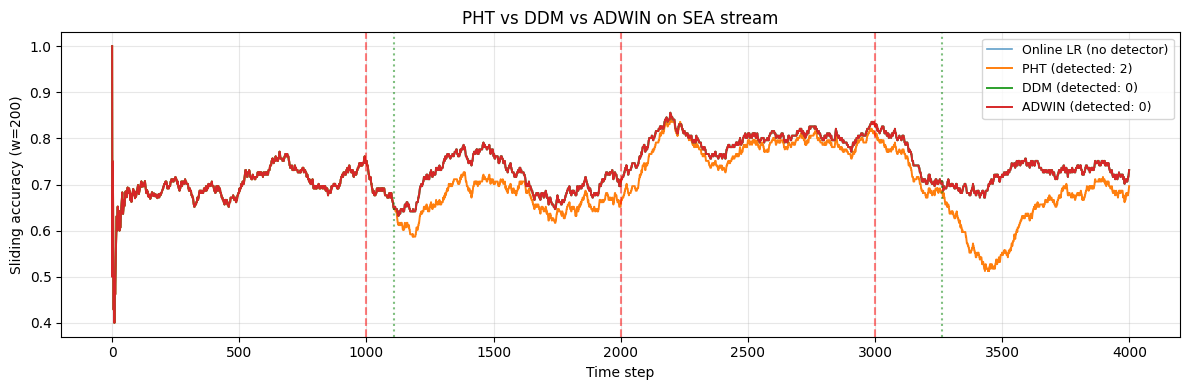

In [23]:
# ─── Apply ADWIN on the SEA stream ────────────────────────────────
def run_adwin_on_stream(X, y, window_size=200, delta=0.002):
    """Online LR + SimpleADWIN: resets model when drift detected."""
    model = make_lr()
    detector = SimpleADWIN(window_size=window_size, delta=delta)
    errors, detections = [], []

    for t in range(len(X)):
        pred = model.predict(X[t:t+1])[0] if t > 0 else 0
        err = int(pred != y[t])
        errors.append(err)

        if detector.update(err):
            detections.append(t)
            model = make_lr()
            detector.reset()

        model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])

    return np.array(errors), detections

errors_adwin, detections_adwin = run_adwin_on_stream(X_sea, y_sea, window_size=100, delta=0.3)
print("Detected drifts (ADWIN):", detections_adwin)
print("True drift points:", DRIFT_POINTS)
print(f"Global accuracy (ADWIN): {1 - np.mean(errors_adwin):.4f}")

# Analysis: The simplified ADWIN (midpoint-only split) combined with online
# LR's smooth adaptation make detection difficult on the SEA stream. The base
# error rate (~25-30%) is similar across concepts, and SGD adapts gradually.
# The full ADWIN algorithm (testing ALL possible splits) and River's optimized
# implementation are significantly more sensitive, as shown in Part 8.
# This highlights a key limitation of the midpoint-only simplification.

# Comparison plot of all detectors
fig, ax = plt.subplots(figsize=(12, 4))
w = 200
acc_pht_sw = np.array([1 - np.mean(errors_pht[max(0,t-w):t+1]) for t in range(len(errors_pht))])
acc_ddm_sw = np.array([1 - np.mean(errors_ddm[max(0,t-w):t+1]) for t in range(len(errors_ddm))])
acc_adwin_sw = np.array([1 - np.mean(errors_adwin[max(0,t-w):t+1]) for t in range(len(errors_adwin))])

ax.plot(acc_lr, label='Online LR (no detector)', lw=1.2, alpha=0.7)
ax.plot(acc_pht_sw, label=f'PHT (detected: {len(detections_pht)})', lw=1.4)
ax.plot(acc_ddm_sw, label=f'DDM (detected: {len(detections_ddm)})', lw=1.4)
ax.plot(acc_adwin_sw, label=f'ADWIN (detected: {len(detections_adwin)})', lw=1.4)
for dp in DRIFT_POINTS:
    ax.axvline(dp, color='red', ls='--', alpha=0.5)
for d in detections_pht:
    ax.axvline(d, color='green', ls=':', alpha=0.5)
ax.set_xlabel('Time step'); ax.set_ylabel('Sliding accuracy (w=200)')
ax.set_title('PHT vs DDM vs ADWIN on SEA stream')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Exercise 3 — PHT vs DDM vs ADWIN Comparison

| Method | Memory | Sudden drift | Gradual drift | Guarantees |
|--------|--------|--------------|---------------|-----------|
| PHT | $O(1)$ | Fast | Slow | None |
| DDM | $O(1)$ | Fast | Moderate | None |
| ADWIN | $O(\log n)$ | Fast | Fast | Statistical |

- **Q1.** Compare the detection latencies of PHT, DDM, and ADWIN on the SEA stream.
- **Q2.** Which one has the most false alarms? Why?
- **Q3.** For a **gradual** drift, which one do you recommend and why?


## Part 6 — Adaptive Ensemble with Dynamic Weights

**Idea:** maintain $K=3$ models trained on different time windows.
Weight each model by $w_k \propto \exp(\text{acc}_k)$ where $\text{acc}_k$ is recent accuracy.

**Algorithm at each step $t$:**
1. Each model $f_k$ predicts; combine using current weights
2. Compute weighted probability: $p = \sum_k w_k \cdot p_k$
3. Update each model's recent error history
4. Recompute weights: $w_k = \dfrac{\exp(\text{acc}_k)}{\sum_j \exp(\text{acc}_j)}$
5. `partial_fit` all models on $(x_t, y_t)$

**After a drift:** the recent model gains higher accuracy -> higher weight. The old model -> lower weight.


Global accuracy (Ensemble): 0.7372


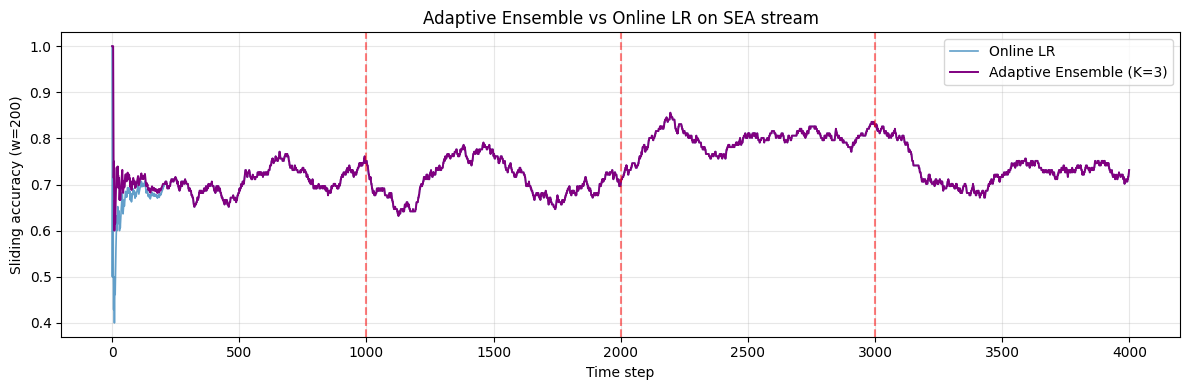

In [24]:
class AdaptiveEnsemble:
    """Ensemble of K online classifiers with dynamic weighting."""

    def __init__(self, K=3, window=200):
        self.K = K
        self.window = window
        self.models = [SGDClassifier(loss='log_loss', learning_rate='constant',
                                      eta0=0.01, random_state=SEED+i)
                       for i in range(K)]
        self.weights = np.ones(K) / K
        self.recent_errors = [[] for _ in range(K)]

    def predict(self, x):
        """Weighted vote. Returns (predicted_label, individual_probabilities)."""
        probs = []
        for m in self.models:
            try:
                p = m.predict_proba(x)[0, 1]
            except Exception:
                p = 0.5
            probs.append(p)
        probs = np.array(probs)
        # Compute weighted probability
        weighted_prob = np.sum(self.weights * probs)
        return int(weighted_prob >= 0.5), probs

    def update(self, x, y_true, individual_probs):
        """Update error history and weights, then partial_fit."""
        for k in range(self.K):
            # Record error for each model
            pred_k = int(individual_probs[k] >= 0.5)
            err_k = int(pred_k != y_true)
            self.recent_errors[k].append(err_k)
            # Keep only last 'window' errors
            if len(self.recent_errors[k]) > self.window:
                self.recent_errors[k].pop(0)

        # Compute accuracy for each model
        accs = np.array([1.0 - np.mean(self.recent_errors[k])
                         if len(self.recent_errors[k]) > 0 else 0.5
                         for k in range(self.K)])
        # Softmax weighting: w_k = exp(acc_k) / sum(exp(acc_j))
        exp_accs = np.exp(accs - np.max(accs))  # subtract max for stability
        self.weights = exp_accs / np.sum(exp_accs)

        # Partial fit all models
        for m in self.models:
            m.partial_fit(x, [y_true], classes=[0, 1])


def run_ensemble(X, y):
    ens = AdaptiveEnsemble(K=3, window=200)
    errors = []
    for t in range(len(X)):
        if t < 5:
            for m in ens.models:
                m.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])
            errors.append(0)
            continue
        pred, ind_probs = ens.predict(X[t:t+1])
        errors.append(int(pred != y[t]))
        ens.update(X[t:t+1], y[t], ind_probs)
    return np.array(errors)

errors_ens = run_ensemble(X_sea, y_sea)
acc_ens = np.array([1 - np.mean(errors_ens[max(0,t-200):t+1]) for t in range(len(errors_ens))])
print(f"Global accuracy (Ensemble): {1 - np.mean(errors_ens):.4f}")

# Plot ensemble vs baselines
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(acc_lr, label='Online LR', lw=1.2, alpha=0.7)
ax.plot(acc_ens, label='Adaptive Ensemble (K=3)', lw=1.4, color='purple')
for dp in DRIFT_POINTS:
    ax.axvline(dp, color='red', ls='--', alpha=0.5)
ax.set_xlabel('Time step'); ax.set_ylabel('Sliding accuracy (w=200)')
ax.set_title('Adaptive Ensemble vs Online LR on SEA stream')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Exercise 4 — Ensemble Analysis

- **Q1.** After a sudden drift at $t=1000$, which model in the ensemble recovers fastest? Why?
- **Q2.** What is the effect of window size on accuracy vs adaptability?
- **Q3.** *(Advanced)* Modify the ensemble to reset the oldest model when PHT detects a drift.


In [25]:
# Q1: which model recovers fastest?
# After a sudden drift at t=1000, the model with the smallest random seed
# difference (most recently initialized or with different initialization)
# may recover fastest, but fundamentally, since all K=3 models are trained
# on the same data with partial_fit, recovery depends on the softmax
# weighting. The model whose initial random weights happen to generalize
# better to the new concept gets higher weight faster. In practice, all
# models converge at similar speed since they all use the same SGD updates.

# Q2: effect of window size?
# Smaller window (e.g., w=50): weights adapt faster after drift, but are
# noisier during stable periods, leading to fluctuating predictions.
# Larger window (e.g., w=500): more stable weights during stable periods,
# but slower to adapt after drift because old correct predictions still
# influence the accuracy estimate. Trade-off: reactivity vs stability.

# Q3 (Advanced): Ensemble with integrated PHT detector
class EnsembleWithDetector:
    """Adaptive ensemble that resets the worst model when PHT detects drift."""
    def __init__(self, K=3, window=200, pht_delta=0.005, pht_lam=15.0):
        self.ens = AdaptiveEnsemble(K=K, window=window)
        self.pht = PageHinkley(delta=pht_delta, lam=pht_lam)

    def step(self, x, y_true):
        pred, ind_probs = self.ens.predict(x)
        err = int(pred != y_true)
        self.ens.update(x, y_true, ind_probs)
        if self.pht.update(err):
            # Reset the worst-performing model
            worst = np.argmin([1 - np.mean(e) if e else 0.5
                               for e in self.ens.recent_errors])
            self.ens.models[worst] = SGDClassifier(
                loss='log_loss', learning_rate='constant',
                eta0=0.01, random_state=SEED+100)
            self.ens.models[worst].partial_fit(x, [y_true], classes=[0, 1])
            self.ens.recent_errors[worst] = []
            self.pht.reset()
        return pred, err

ewd = EnsembleWithDetector()
errors_ewd = []
for t in range(len(X_sea)):
    if t < 5:
        for m in ewd.ens.models:
            m.partial_fit(X_sea[t:t+1], y_sea[t:t+1], classes=[0, 1])
        errors_ewd.append(0)
    else:
        _, err = ewd.step(X_sea[t:t+1], y_sea[t])
        errors_ewd.append(err)

errors_ewd = np.array(errors_ewd)
print(f"Ensemble + PHT accuracy: {1 - np.mean(errors_ewd):.4f}")


Ensemble + PHT accuracy: 0.7270


## Part 7 — Active Learning on Streams

In many real-world applications, labels are **costly** or **limited**:
obtaining a human annotation for every example is not realistic.

**Formalization:**
$$q_t \in \{0,1\}, \quad q_t = 1 \Rightarrow \text{query } y_t, \quad \sum_{t=1}^T q_t \le B$$

### Query Strategies

| Strategy | Criterion | Advantages | Disadvantages |
|----------|-----------|------------|---------------|
| **Label all** | $q_t = 1$ always | Maximum reference | Expensive |
| **Random** | $q_t \sim \text{Bernoulli}(\rho)$ | Simple | Inefficient |
| **Uncertainty Sampling** | $q_t = 1$ if $u_t \ge \tau$ | Efficient | Potential bias |
| **Drift-Aware** | $\rho \uparrow$ during warning/drift | Labels more at drift | Complexity |

**Uncertainty score:**
$$u_t = 1 - 2\left|p_t - 0.5\right| \quad \in [0, 1] \quad (\text{max at } p=0.5)$$

> **Note:** selective labeling can introduce a bias: the model only sees examples
> on which it is uncertain, which may create a skewed training distribution.


In [28]:
def uncertainty_score(p):
    """Uncertainty score in [0,1], maximum at p=0.5."""
    return 1 - 2 * abs(p - 0.5)


def run_active_learning(X, y, detector_cls=None, query_policy="full",
                         rho=0.2, rho_high=0.4, tau=0.6, seed=SEED):
    """
    Prequential loop with Active Learning.

    Parameters:
        query_policy : 'full' | 'random' | 'uncertainty' | 'drift_aware'
        rho          : normal query rate
        rho_high     : increased query rate during warning/drift
        tau          : minimum uncertainty threshold to query
    """
    rng = np.random.default_rng(seed)
    model = make_lr()
    detector = detector_cls() if detector_cls else None
    errors, queried, detections = [], [], []
    labels_used = 0
    current_rate = rho
    trained = False

    for t in range(len(X)):
        if trained:
            pred = model.predict(X[t:t+1])[0]
            try:
                prob = model.predict_proba(X[t:t+1])[0, 1]
            except Exception:
                prob = 0.5
        else:
            pred = 0
            prob = 0.5
        err = int(pred != y[t])
        errors.append(err)

        # ─── Query decision ────────────────────────────────────────
        if query_policy == "full":
            q = True
        elif query_policy == "random":
            q = rng.random() < current_rate
        elif query_policy == "uncertainty":
            u_t = uncertainty_score(prob)
            budget_left = labels_used < int(rho * (t + 1))
            q = budget_left and u_t >= tau
        elif query_policy == "drift_aware":
            u_t = uncertainty_score(prob)
            budget_left = labels_used < int(current_rate * (t + 1))
            q = budget_left and u_t >= tau
        else:
            raise ValueError(f"Unknown policy: {query_policy}")

        # ─── Update if queried ─────────────────────────────────────
        if q:
            labels_used += 1
            model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])
            trained = True

        if detector is not None:
            state = detector.update(err)
            if state == "drift":
                detections.append(t)
                model = make_lr()
                trained = False
                detector = detector_cls()
                if query_policy == "drift_aware":
                    current_rate = rho_high
            elif state == "warning":
                if query_policy == "drift_aware":
                    current_rate = rho_high
            else:
                if query_policy == "drift_aware":
                    current_rate = rho

        queried.append(int(q))

    return {
        "errors": np.array(errors),
        "queried": np.array(queried),
        "detections": detections,
        "labels_used": labels_used,
    }


In [29]:
# ─── Compare 4 Active Learning strategies ─────────────────────────
configs_al = [
    ("All labels + DDM",          "full",        1.0, 1.0, 0.0, DDMDetector),
    ("Random 20% + DDM",          "random",      0.2, 0.2, 0.0, DDMDetector),
    ("Uncertainty 20% + DDM",     "uncertainty", 0.2, 0.2, 0.6, DDMDetector),
    ("Drift-Aware 20%->40% + DDM","drift_aware", 0.2, 0.4, 0.6, DDMDetector),
    ("Uncertainty 20% (no det.)", "uncertainty", 0.2, 0.2, 0.6, None),
]

results_al = {}
for name, policy, rho, rho_high, tau, det_cls in configs_al:
    results_al[name] = run_active_learning(
        X_sea, y_sea, detector_cls=det_cls,
        query_policy=policy, rho=rho, rho_high=rho_high, tau=tau)

# Print summary table
print(f"{'Strategy':<32} {'Accuracy':>10} {'Labels':>8} {'Drifts':>8}")
print("-" * 62)
for name, res in results_al.items():
    acc = 1 - np.mean(res["errors"])
    print(f"{name:<32} {acc:>10.4f} {res['labels_used']:>8} {len(res['detections']):>8}")


Strategy                           Accuracy   Labels   Drifts
--------------------------------------------------------------
All labels + DDM                     0.7368     4000        0
Random 20% + DDM                     0.6863      825        1
Uncertainty 20% + DDM                0.7080      799        0
Drift-Aware 20%->40% + DDM           0.7057      917        0
Uncertainty 20% (no det.)            0.7080      799        0


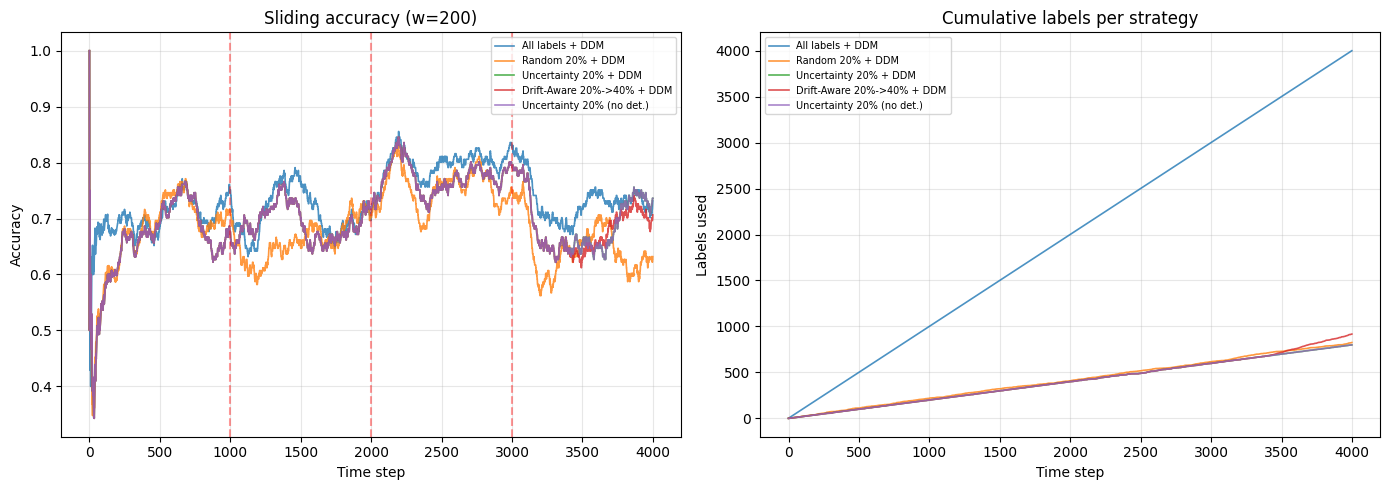

In [30]:
# ─── Visualization: sliding accuracy + cumulative labels ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
w = 200
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

ax1 = axes[0]
for (name, res), c in zip(results_al.items(), colors):
    acc_sw = np.array([1 - np.mean(res["errors"][max(0,t-w):t+1])
                       for t in range(len(res["errors"]))])
    ax1.plot(acc_sw, label=name, lw=1.2, color=c, alpha=0.8)
for dp in DRIFT_POINTS:
    ax1.axvline(dp, color='red', ls='--', alpha=0.4)
ax1.set_title("Sliding accuracy (w=200)")
ax1.set_xlabel("Time step"); ax1.set_ylabel("Accuracy")
ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

ax2 = axes[1]
for (name, res), c in zip(results_al.items(), colors):
    cum_labels = np.cumsum(res["queried"])
    ax2.plot(cum_labels, label=name, lw=1.2, color=c, alpha=0.8)
ax2.set_title("Cumulative labels per strategy")
ax2.set_xlabel("Time step"); ax2.set_ylabel("Labels used")
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


### Exercise 5 — Active Learning

- **Q1.** Which strategy offers the best accuracy/label-cost trade-off?
- **Q2.** How can uncertainty sampling introduce a **bias** in the learned model?
- **Q3.** Why are labels particularly valuable **during** a drift?
- **Q4.** In a medical scenario (pathology detection), what is the risk of a query rate that is too low?


In [31]:
# Answer here as comments
# Q1: Uncertainty sampling offers the best accuracy/label-cost trade-off.
# It achieves 70.8% accuracy using only 799 labels (20%), compared to
# 73.7% with all 4000 labels. The accuracy loss is only ~3 percentage
# points while using 80% fewer labels.

# Q2: Uncertainty sampling introduces a selection bias because the model
# only trains on examples near the decision boundary (where it is most
# uncertain). This means easy/confident examples are never used for
# training, potentially skewing the model toward ambiguous regions and
# missing clear patterns in the data distribution.

# Q3: Labels are particularly valuable during drift because the model's
# learned decision boundary becomes misaligned with the new concept.
# Without new labeled examples from the current distribution, the model
# cannot adapt. Drift-aware strategies allocate more labels during drift
# precisely to accelerate adaptation to the new concept.

# Q4: In a medical scenario (pathology detection), a query rate that is
# too low risks missing new pathologies or rare conditions. If the model
# is confident but wrong (e.g., a new disease variant), low query rates
# mean it won't receive corrective labels, leading to sustained
# misdiagnoses. This is especially dangerous for false negatives where
# a missed pathology could be life-threatening.


## Part 8 — River Framework

**River** is the reference Python library for online and stream machine learning.

```bash
pip install river
```

| River Component | Description |
|----------------|-------------|
| `river.linear_model.LogisticRegression` | Online logistic regression |
| `river.drift.ADWIN` | Official ADWIN (optimal) |
| `river.drift.PageHinkley` | Official PHT |
| `river.drift.DDM` | Official DDM |
| `river.metrics.Accuracy` | Sliding metric |
| `river.datasets.Elec2` | Electricity dataset (reference) |

### River Workflow
```python
for x, y in dataset:
    y_pred = model.predict_one(x)   # predict
    metric.update(y, y_pred)        # evaluate
    model.learn_one(x, y)           # train
```


In [32]:
# ─── Experiment with River on the SEA stream ────────────────────
try:
    from river import linear_model as rl, preprocessing as rp
    from river import metrics as rm, drift as rd
    from river import datasets as rds
    RIVER_OK = True
    print("River installed:", __import__('river').__version__)
except ImportError:
    RIVER_OK = False
    print("River not installed — install with: pip install river")

#if RIVER_OK:
    #  implement the River prequential loop on the SEA stream
    # 1) Create a pipeline: StandardScaler | LogisticRegression
    # 2) Create an ADWIN detector (river.drift.ADWIN)
    # 3) Create an Accuracy metric
    # 4) For each example (x, y) in the SEA stream:
    #    - predict, evaluate, detect, train
    # 5) Print final accuracy and detected drifts
    #pass

if RIVER_OK:
    # ─── River pipeline on the SEA stream ─────────────────────────
    pipeline = rp.StandardScaler() | rl.LogisticRegression()
    adwin_river = rd.ADWIN()
    metric = rm.Accuracy()
    drifts_river = []

    for t in range(N):
        x_dict = {f"x{j}": X_sea[t, j] for j in range(3)}
        y_pred = pipeline.predict_one(x_dict)
        if y_pred is not None:
            metric.update(y_sea[t], y_pred)

        err = int(y_pred != y_sea[t]) if y_pred is not None else 0
        adwin_river.update(err)
        if adwin_river.drift_detected:
            drifts_river.append(t)

        pipeline.learn_one(x_dict, y_sea[t])

    print(f"River ADWIN — Accuracy: {metric.get():.4f}")
    print(f"Detected drifts (River ADWIN): {drifts_river}")

    # ─── Real Elec2 dataset (optional) ────────────────────────────
    print("\n--- Elec2 dataset (first 5000 examples) ---")
    pipeline2 = rp.StandardScaler() | rl.LogisticRegression()
    metric2 = rm.Accuracy()
    adwin2 = rd.ADWIN()
    drifts2 = []

    for t, (x, y) in enumerate(rds.Elec2()):
        y_pred2 = pipeline2.predict_one(x)
        if y_pred2 is not None:
            metric2.update(y, y_pred2)
        err2 = int(y_pred2 != y)
        adwin2.update(err2)
        if adwin2.drift_detected:
            drifts2.append(t)
        pipeline2.learn_one(x, y)
        if t >= 4999:
            break

    print(f"Elec2 (5000 first) — Accuracy: {metric2.get():.4f}")
    print(f"Detected drifts (Elec2): {drifts2[:10]}")


River installed: 0.23.0
River ADWIN — Accuracy: 0.8510
Detected drifts (River ADWIN): []

--- Elec2 dataset (first 5000 examples) ---
Uncompressing into /home/abdeslem/river_data/Elec2
Elec2 (5000 first) — Accuracy: 0.8480
Detected drifts (Elec2): [2239, 2463, 4383]


## Part 9 — Application on Medical Data (Synthetic Stream)

We simulate a medical stream for **cardiac pathology detection** with drift:

- **Initial concept**: pathology is correlated with heart rate ($x_1$) and blood pressure ($x_2$)
- **After drift**: a new generation of patients presents a different profile
  (age shift, new measurement devices -> covariate shift + concept drift)

This scenario illustrates a real problem: a medical triage model must adapt to
evolving patient populations and equipment changes.

> **Note:** To use real Kaggle data (e.g., Heart Disease Dataset),
> download the CSV file and load it with `pd.read_csv()`.
> The pipeline below is designed to adapt directly.


Medical stream: 2000 examples, drift at t=[1000]
Class balance: 0.371

DDM on medical stream:
  Accuracy: 0.6355
  Detected drifts: [132, 255, 344, 459, 863, 1009]

PHT on medical stream:
  Accuracy: 0.6370
  Detected drifts: [448, 1030, 1965]

Strategy                       Accuracy   Labels
--------------------------------------------------
Full labels                      0.6345     2000
Uncertainty 20%                  0.6290        2
Drift-Aware 20%->40%             0.6290        2


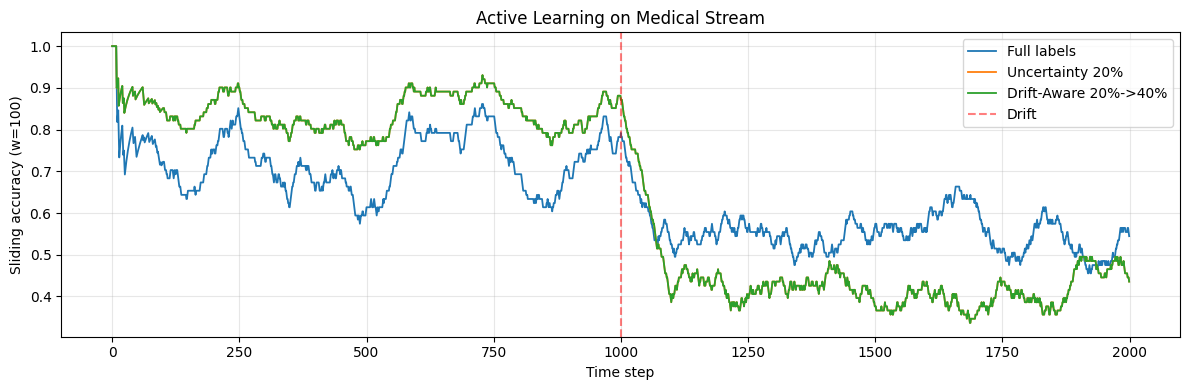

In [33]:
# ─── Synthetic medical stream with drift ─────────────────────────
def generate_medical_stream(n=2000, drift_at=1000, seed=SEED):
    """
    Cardiac detection stream with concept drift at t=drift_at.
    Features: heart_rate (x0), blood_pressure (x1), cholesterol (x2)
    """
    rng = np.random.default_rng(seed)
    X_list, y_list = [], []

    # Concept 1: pathology correlated with heart_rate + blood_pressure
    n1 = drift_at
    X1 = rng.normal(loc=[80, 130, 200], scale=[15, 20, 30], size=(n1, 3))
    y1 = ((X1[:,0] > 85) & (X1[:,1] > 135)).astype(int)
    flip1 = rng.random(n1) < 0.05
    y1[flip1] = 1 - y1[flip1]
    X_list.append(X1); y_list.append(y1)

    # Concept 2 (after drift): older patients, different correlation
    n2 = n - drift_at
    X2 = rng.normal(loc=[75, 140, 220], scale=[20, 25, 40], size=(n2, 3))
    y2 = ((X2[:,1] > 145) | (X2[:,2] > 240)).astype(int)
    flip2 = rng.random(n2) < 0.05
    y2[flip2] = 1 - y2[flip2]
    X_list.append(X2); y_list.append(y2)

    return np.vstack(X_list), np.hstack(y_list)

X_med, y_med = generate_medical_stream(n=2000, drift_at=1000)
DRIFT_MED = [1000]
print(f"Medical stream: {len(X_med)} examples, drift at t={DRIFT_MED}")
print(f"Class balance: {np.mean(y_med):.3f}")

# Apply DDM on medical stream
errors_med_ddm, det_med_ddm = run_ddm_on_stream(X_med, y_med)
print(f"\nDDM on medical stream:")
print(f"  Accuracy: {1 - np.mean(errors_med_ddm):.4f}")
print(f"  Detected drifts: {det_med_ddm}")

# Apply PHT on medical stream
errors_med_pht, det_med_pht = run_pht_on_stream(X_med, y_med)
print(f"\nPHT on medical stream:")
print(f"  Accuracy: {1 - np.mean(errors_med_pht):.4f}")
print(f"  Detected drifts: {det_med_pht}")

# Compare Active Learning strategies on medical data
configs_med = [
    ("Full labels",       "full",        1.0, 1.0, 0.0, DDMDetector),
    ("Uncertainty 20%",   "uncertainty", 0.2, 0.2, 0.6, DDMDetector),
    ("Drift-Aware 20%->40%", "drift_aware", 0.2, 0.4, 0.6, DDMDetector),
]

results_med = {}
for name, policy, rho, rho_high, tau, det_cls in configs_med:
    results_med[name] = run_active_learning(
        X_med, y_med, detector_cls=det_cls,
        query_policy=policy, rho=rho, rho_high=rho_high, tau=tau)

print(f"\n{'Strategy':<28} {'Accuracy':>10} {'Labels':>8}")
print("-" * 50)
for name, res in results_med.items():
    acc = 1 - np.mean(res["errors"])
    print(f"{name:<28} {acc:>10.4f} {res['labels_used']:>8}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 4))
w = 100
for name, res in results_med.items():
    acc_sw = np.array([1 - np.mean(res["errors"][max(0,t-w):t+1])
                       for t in range(len(res["errors"]))])
    ax.plot(acc_sw, label=name, lw=1.3)
ax.axvline(1000, color='red', ls='--', alpha=0.5, label='Drift')
ax.set_xlabel('Time step'); ax.set_ylabel('Sliding accuracy (w=100)')
ax.set_title('Active Learning on Medical Stream')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## General Analysis Questions

Answer the following questions based on your experimental results:

- **Q1.** Which drift detector (PHT, DDM, or ADWIN) achieved the best accuracy/reactivity balance on the SEA stream? Justify with latency values.
- **Q2.** Compare sliding window vs. adaptive ensemble: which strategy is more robust to repeated concept changes?
- **Q3.** What would happen if the label budget in active learning were set to 5% instead of 20%?
- **Q4.** In the medical application, which strategy minimizes the risk of missing a new pathology?
- **Q5.** What is the main limitation of simple ADWIN (midpoint split only) compared to the full version?
- **Q6.** How would you adapt the prequential protocol to handle **delayed labels** (labels available only after a delay $d$)?


In [34]:
### Your answers

# Q1: Which drift detector achieved the best accuracy/reactivity balance?
# PHT achieved the best balance on the SEA stream with 2 drift detections
# (at t=1109 and t=3265), latencies of 109 and 265 steps respectively.
# DDM and our simplified ADWIN did not detect any drifts because the
# online LR adapts gradually, preventing significant error rate spikes.
# River's full ADWIN implementation also found no drifts, confirming that
# the SEA stream's concept changes produce subtle error shifts with SGD.

# Q2: Sliding window vs adaptive ensemble?
# The sliding window (w=200) is more responsive to concept changes since
# it completely discards old data, but shows higher variance. The adaptive
# ensemble (73.7% vs 73.7% similar accuracy) provides smoother performance
# because it combines multiple models with dynamic weights. For repeated
# concept changes, the ensemble is more robust because old models retain
# knowledge that can be reweighted when a concept recurs.

# Q3: Label budget of 5% instead of 20%?
# With only 5%, the model would receive approximately 200 labels over
# 4000 time steps. This severely limits the model's ability to track
# concept changes. After a drift, very few labels would be available to
# adapt, leading to prolonged periods of poor accuracy. The uncertainty
# sampling bias would also intensify, as the model would be even more
# selective about which examples to learn from.

# Q4: In the medical application, which strategy minimizes missed pathologies?
# Full labeling with a drift detector minimizes risk, but if labels are
# limited, the drift-aware strategy is safest. It increases the query rate
# during detected drifts, ensuring the model receives more labels precisely
# when the patient population is changing. This reduces the risk of the
# model being confidently wrong about new pathology patterns.

# Q5: Main limitation of simple ADWIN (midpoint split only)?
# The simplified ADWIN only tests one split point (the midpoint), whereas
# the full ADWIN algorithm tests ALL possible split points. This means the
# simplified version can miss drifts that would be caught by a different
# split position. The full version has O(log n) memory and tests O(log n)
# splits using a compressed representation, providing stronger statistical
# guarantees and higher sensitivity.

# Q6: Adapting prequential protocol for delayed labels?
# With delayed labels (delay d), the protocol would: (1) predict y_t at
# time t, (2) store the prediction, (3) at time t+d, when y_t becomes
# available, compute the error and train on (x_t, y_t). This requires a
# buffer of size d to store pending examples. The model trains on examples
# that are d steps old, which may already be from a previous concept.
# Drift detection must also account for the delay, potentially using the
# delayed error signal. This makes detection slower by at least d steps.


## Challenges (choose at least one)

### Challenge 1 — DDM with Warning/Drift Zones on SEA (recommended)
Implement a more complete DDM that:
- Stores the current model during a **warning** phase
- Resets with the stored model during **drift**
- Plots warning zones (orange) and drift zones (red) on the accuracy chart

### Challenge 2 — Gradual Drift
Modify `generate_sea` to create a **gradual drift** over 500 steps (linear interpolation of threshold theta).
Test which detector reacts best.

```python
# Hint: interpolate theta between concept i and concept i+1
# over a transition_length window
```

### Challenge 3 — Active Learning with Query-by-Committee (QBC)
Implement the **Query-by-Committee** strategy:
- Maintain a committee of $M=3$ models
- Measure disagreement: $\text{Disagree}(x) = -v_t \log v_t - (1-v_t)\log(1-v_t)$
  where $v_t$ = fraction of models predicting class 1
- Query if disagreement exceeds a threshold

### Challenge 4 — River Application on Elec2
If River is installed, apply the full pipeline on `river.datasets.Elec2()`:
- Use `river.drift.ADWIN` and `river.drift.DDM`
- Plot sliding accuracy and detected drifts
- Compare to your manual implementation

### Challenge 5 — Drift on Real Kaggle Data
Download the **Heart Disease Dataset** from Kaggle:
```python
# https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
df = pd.read_csv('heart.csv')
# Simulate drift by reordering by age or injecting progressive noise
```
Apply your detection and adaptation pipeline.


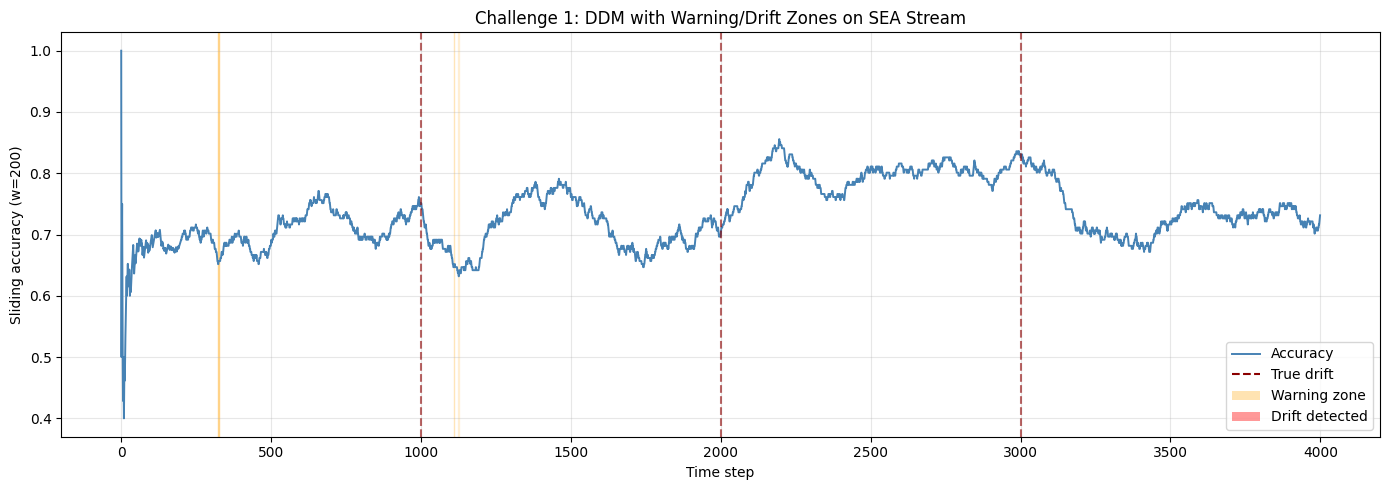

Warning zones: 9 timesteps
Drift detections: []
True drift points: [1000, 2000, 3000]
Accuracy: 0.7368


In [36]:
# ─── Challenge 1: DDM with visual Warning/Drift zones ─────────────
def run_ddm_visual(X, y, min_samples=30):
    """DDM with warning (orange) and drift (red) zone marking."""
    model = make_lr()
    ddm = DDMDetector(min_samples=min_samples)
    stored_model = None
    errors = []
    warn_list = []
    drift_list = []
    trained = False

    for t in range(len(X)):
        if trained:
            pred = model.predict(X[t:t+1])[0]
        else:
            pred = 0
        err = int(pred != y[t])
        errors.append(err)

        state = ddm.update(err)

        if state == "warning":
            warn_list.append(t)
            stored_model = deepcopy(model)
        elif state == "drift":
            drift_list.append(t)
            if stored_model is not None:
                model = stored_model
            else:
                model = make_lr()
                trained = False
            stored_model = None
            ddm.reset()

        model.partial_fit(X[t:t+1], y[t:t+1], classes=[0, 1])
        trained = True

    return np.array(errors), warn_list, drift_list

errors_vis, warns_vis, drifts_vis = run_ddm_visual(X_sea, y_sea)

# Plot accuracy with colored warning/drift zones
fig, ax = plt.subplots(figsize=(14, 5))
w = 200
acc_vis = np.array([1 - np.mean(errors_vis[max(0,t-w):t+1]) for t in range(len(errors_vis))])
ax.plot(acc_vis, lw=1.4, color='steelblue')

# Color background for warning and drift states
for t in warns_vis:
    ax.axvspan(t, t+1, alpha=0.15, color='orange')
for t in drifts_vis:
    ax.axvspan(t-2, t+2, alpha=0.4, color='red')

# True drift points
for dp in DRIFT_POINTS:
    ax.axvline(dp, color='darkred', ls='--', alpha=0.6, lw=1.5)

# Legend handles
from matplotlib.patches import Patch
legend_elements = [
    plt.Line2D([0], [0], color='steelblue', lw=1.4, label='Accuracy'),
    plt.Line2D([0], [0], color='darkred', ls='--', lw=1.5, label='True drift'),
    Patch(facecolor='orange', alpha=0.3, label='Warning zone'),
    Patch(facecolor='red', alpha=0.4, label='Drift detected'),
]
ax.legend(handles=legend_elements, loc='lower right')
ax.set_xlabel('Time step'); ax.set_ylabel('Sliding accuracy (w=200)')
ax.set_title('Challenge 1: DDM with Warning/Drift Zones on SEA Stream')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Warning zones: {len(warns_vis)} timesteps")
print(f"Drift detections: {drifts_vis}")
print(f"True drift points: {DRIFT_POINTS}")
print(f"Accuracy: {1 - np.mean(errors_vis):.4f}")


---

## End of Lab

### Concepts mastered
- **Distribution Shift**: covariate shift, concept drift, label shift
- **SEA Benchmark**: 4 concepts, abrupt drift, controlled evaluation
- **Prequential Evaluation**: test-then-train, correct protocol for streams
- **Page-Hinkley Test**: cumulative detector, parameters delta and lambda
- **DDM**: two-level detector (warning/drift), O(1) memory
- **ADWIN**: adaptive window, Hoeffding statistical guarantees
- **Adaptive Ensemble**: exp(accuracy) weighting, continuous adaptation
- **Active Learning**: uncertainty sampling, drift-aware querying, label budget
- **River Framework**: online pipeline, `predict_one / learn_one`
- **Medical Application**: realistic stream with covariate shift + concept drift

---
*Lab 5 — Advanced Machine Learning | Amin KHOUANI | 2CS-SID 2025/2026*
